Gerando trajetórias clínicas (Slope Charts)...


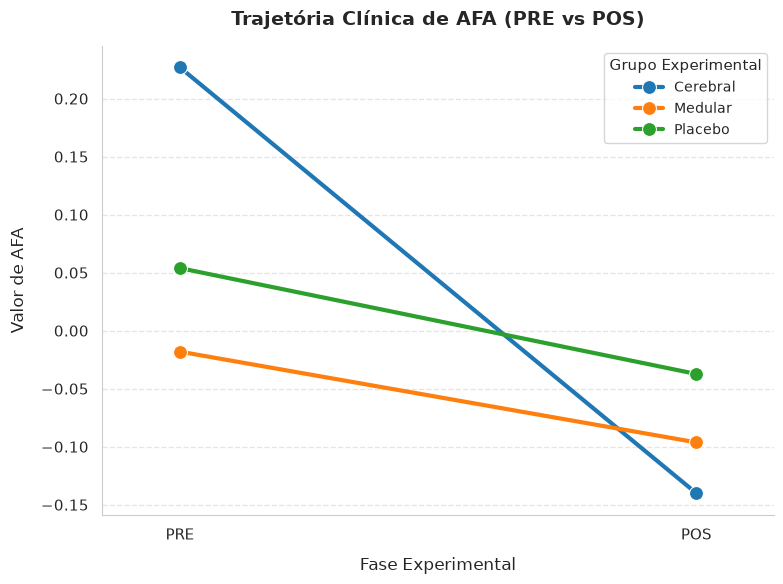

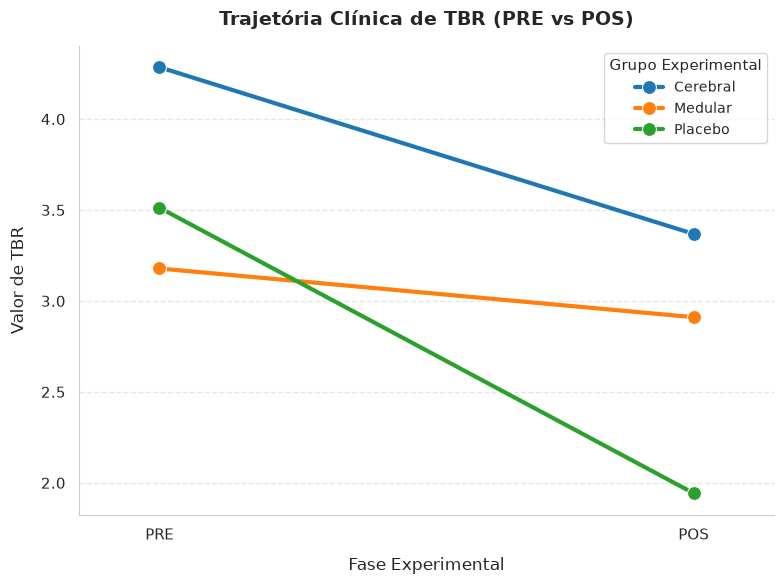

Gerando gráficos de barras agrupadas...


/tmp/ipykernel_2569/3193903073.py:95: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


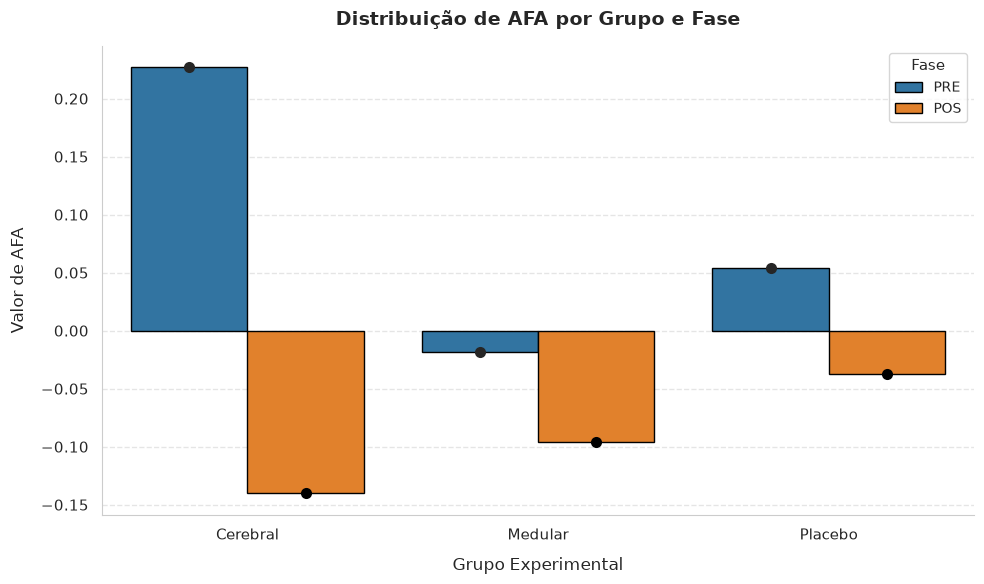

/tmp/ipykernel_2569/3193903073.py:95: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


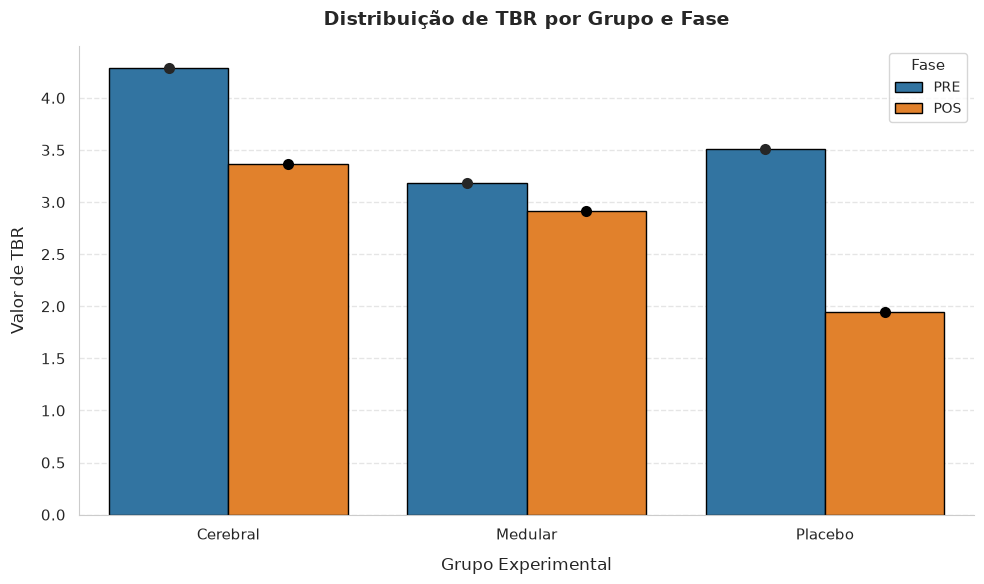

In [ ]:
# VISUALIZAÇÕES CLÍNICAS (AFA e TBR)

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregamento e Validação dos Dados
# Garante que o script não execute cegamente se o arquivo não existir
csv_path = "dados_mestrado_finais.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"ERRO: O arquivo {csv_path} não foi encontrado. Execute o pipeline de extração primeiro.")

df = pd.read_csv(csv_path)

# 2. Organização Metodológica Estrutural
mapa_grupos = {'G1': 'Cerebral', 'G2': 'Medular', 'G3': 'Placebo'}
df['grupo'] = df['grupo'].map(mapa_grupos)

# Transformação em variáveis categóricas ordenadas
# Blinda o código contra ordenação alfabética padrão, forçando a hierarquia do desenho experimental
df['fase'] = pd.Categorical(df['fase'], categories=['PRE', 'POS'], ordered=True)
df['grupo'] = pd.Categorical(df['grupo'], categories=['Cerebral', 'Medular', 'Placebo'], ordered=True)

# Ordenação final do dataframe para segurança do plot
df = df.sort_values(by=['grupo', 'fase'])

# 3. Definição das Assinaturas Clínicas
biomarcadores = ['AFA', 'TBR']

# 4. Configuração Estética Acadêmica (High Data-Ink Ratio)
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

# Paletas de cores rigorosas e customizadas
cores_grupos = {'Cerebral': '#1f77b4', 'Medular': '#ff7f0e', 'Placebo': '#2ca02c'}
cores_fases = {'PRE': "#1f77b4", 'POS': "#ff7f0e"}

# ==========================================
# PARTE 1: Gráficos de Trajetória (Slope Charts)
# Evidenciar a direção e a magnitude da modulação intra-sujeito.
# ==========================================
print("Gerando Slope Charts...")

for bio in biomarcadores:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Utiliza-se hue_order para forçar a sequência correta na legenda
    sns.lineplot(
        data=df, x='fase', y=bio, hue='grupo',
        palette=cores_grupos, marker='o', linewidth=3, markersize=10, ax=ax,
        hue_order=['Cerebral', 'Medular', 'Placebo']
    )
    
    ax.set_title(f'Trajetória Clínica de {bio} (PRE vs POS)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Fase Experimental', fontsize=12, labelpad=10)
    ax.set_ylabel(f'Valor de {bio}', fontsize=12, labelpad=10)
    
    # Expansão simétrica do eixo X para os marcadores não serem cortados pelas bordas
    ax.set_xlim(-0.15, 1.15)
    
    # Despine total e grade de orientação horizontal
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Configuração explícita da legenda
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title='Grupo Experimental', title_fontsize='11', fontsize='10', frameon=True)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# PARTE 2: Gráficos de Barras Agrupadas
# Contrastar transversalmente os grupos utilizando medidas absolutas.
# ==========================================
print("Gerando gráficos de barras agrupadas...")

for bio in biomarcadores:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # O argumento order utiliza a nomenclatura atualizada ('Cerebral', 'Medular', 'Placebo')
    sns.barplot(
        data=df, x='grupo', y=bio, hue='fase',
        palette=cores_fases, edgecolor='black', linewidth=1, ax=ax,
        order=['Cerebral', 'Medular', 'Placebo'], 
        hue_order=['PRE', 'POS']
    )
    
    # Adicionando os pontos individuais (stripplot) para total transparência de dados (vital para N pequeno)
    sns.stripplot(
        data=df, x='grupo', y=bio, hue='fase',
        dodge=True, color='black', size=8, jitter=False, ax=ax,
        order=['Cerebral', 'Medular', 'Placebo'], 
        hue_order=['PRE', 'POS']
    )
    
    ax.set_title(f'Distribuição de {bio} por Grupo e Fase', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Grupo Experimental', fontsize=12, labelpad=10)
    ax.set_ylabel(f'Valor de {bio}', fontsize=12, labelpad=10)
    
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Limpeza da legenda (o stripplot duplica os ícones, esta técnica isola apenas os da barra)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Fase', title_fontsize='11', fontsize='10', frameon=True)
    
    plt.tight_layout()
    plt.show()

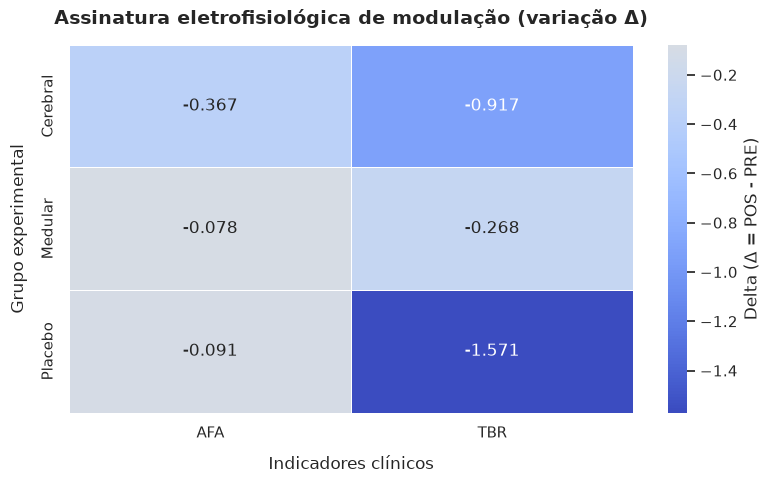

In [ ]:
# VISUALIZAÇÃO MULTIMODAL: HEATMAP DE VARIAÇÃO (DELTA)

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregamento e Validação
csv_path = "dados_mestrado_finais.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"ERRO: O arquivo {csv_path} não foi encontrado.")

df = pd.read_csv(csv_path)

# 2. Organização Metodológica
# Traduzimos os grupos mantendo o rigor da sua nomenclatura
mapa_grupos = {'G1': 'Cerebral', 'G2': 'Medular', 'G3': 'Placebo'}
df['grupo'] = df['grupo'].map(mapa_grupos)

# 3. Engenharia de Dados: O Cálculo do Delta
biomarcadores = ['AFA', 'TBR']

# Pivotamos a tabela para colocar PRE e POS lado a lado, facilitando a subtração matemática
df_pivot = df.pivot(index='grupo', columns='fase', values=biomarcadores)

# Construímos um novo dataframe puramente para as variações
df_delta = pd.DataFrame(index=df_pivot.index)
for bio in biomarcadores:
    # A operação essencial da neuromodulação transversal: PÓS menos PRÉ
    df_delta[bio] = df_pivot[bio]['POS'] - df_pivot[bio]['PRE']

# Forçamos a ordenação hierárquica das linhas para manter o padrão visual
df_delta = df_delta.reindex(['Cerebral', 'Medular', 'Placebo'])

# 4. Configuração Estética Acadêmica
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(8, 5))

# Plotagem do Heatmap
sns.heatmap(
    df_delta, 
    annot=True,          # Imprime o valor exato do Delta dentro da célula
    fmt=".3f",           # Fixa 3 casas decimais para rigor científico
    cmap='coolwarm',     # Paleta divergente (Azul = Queda, Vermelho = Aumento)
    center=0,            # Ponto de ancoragem metodológica: Branco = 0 (Sem alteração)
    linewidths=.5,       # Linhas de grade sutis entre as células
    cbar_kws={'label': 'Delta (\u0394 = POS - PRE)'}, 
    ax=ax
)

ax.set_title('Assinatura eletrofisiológica de modulação (variação \u0394)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Indicadores clínicos', fontsize=12, labelpad=10)
ax.set_ylabel('Grupo experimental', fontsize=12, labelpad=10)

# Correção tipográfica para os rótulos do eixo X ficarem na horizontal
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

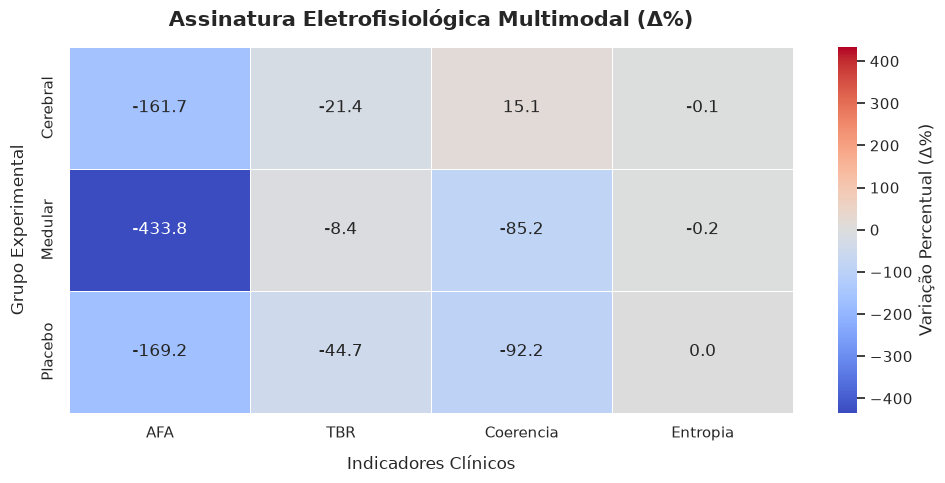

In [13]:
# VISUALIZAÇÃO MULTIMODAL: HEATMAP DE VARIAÇÃO PERCENTUAL

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregamento e Validação
csv_path = "dados_mestrado_finais.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"ERRO: O arquivo {csv_path} não foi encontrado.")

df = pd.read_csv(csv_path)

# 2. Organização Metodológica
mapa_grupos = {'G1': 'Cerebral', 'G2': 'Medular', 'G3': 'Placebo'}
df['grupo'] = df['grupo'].map(mapa_grupos)

# 3. Engenharia de Dados: Cálculo do Delta Percentual
# Expandimos para todos os biomarcadores relevantes
biomarcadores = ['AFA', 'TBR', 'Alpha_Relativo', 'Coerencia', 'Entropia']

# Verificar se as colunas extras existem no dataframe; se não, manter apenas as disponíveis
colunas_disponiveis = [b for b in biomarcadores if b in df.columns]

df_pivot = df.pivot(index='grupo', columns='fase', values=colunas_disponiveis)
df_delta_pct = pd.DataFrame(index=df_pivot.index)

for bio in colunas_disponiveis:
    # Fórmula: ((POS - PRE) / |PRE|) * 100
    # Usamos o valor absoluto no denominador para evitar inversões de sinal se o PRE for negativo (ex: AFA)
    df_delta_pct[bio] = ((df_pivot[bio]['POS'] - df_pivot[bio]['PRE']) / df_pivot[bio]['PRE'].abs()) * 100

# Forçamos a ordenação hierárquica
df_delta_pct = df_delta_pct.reindex(['Cerebral', 'Medular', 'Placebo'])

# 4. Configuração Estética Acadêmica (Painel Expandido)
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Ajustamos o tamanho da figura para acomodar mais colunas
fig, ax = plt.subplots(figsize=(10, 5))

# Para garantir que o branco seja exatamente o 0%, achamos o valor máximo absoluto da tabela
# Isso evita que a escala fique "torta" (ex: indo de -50 a +10)
vmax_abs = np.max(np.abs(df_delta_pct.values))

sns.heatmap(
    df_delta_pct, 
    annot=True,          
    fmt=".1f",           # 1 casa decimal é suficiente para porcentagem
    cmap='coolwarm',     
    center=0,            
    vmin=-vmax_abs,      # Trava o limite inferior
    vmax=vmax_abs,       # Trava o limite superior simétrico
    linewidths=.5,       
    cbar_kws={'label': 'Variação Percentual (\u0394%)'}, 
    ax=ax
)

ax.set_title('Assinatura Eletrofisiológica Multimodal (\u0394%)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Indicadores Clínicos', fontsize=12, labelpad=10)
ax.set_ylabel('Grupo Experimental', fontsize=12, labelpad=10)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()